# HDSD Dataset Preparation and Baseline Evaluation using Whisper-small

In [1]:
#access the close talk (M2) microphone for baseline whisper and the corresponding transcripts.

## 1. Imports and Configuration

In [4]:
#imports
import os
import random
import numpy as np

import pandas as pd
import librosa
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ModuleNotFoundError: No module named 'numpy'

## 2. Dataset Construction

In [5]:
#paths
HDSD_ROOT = r"C:\Users\edwin\OneDrive\Desktop\Capstone\hindi indic\HDSD"
AUDIO_ROOT = os.path.join(HDSD_ROOT, "hindi_sent")
TRANSCRIPT_ROOT = os.path.join(HDSD_ROOT, "WORD")

In [5]:
dataset_rows = []

for speaker in os.listdir(AUDIO_ROOT):
    speaker_audio_dir = os.path.join(AUDIO_ROOT, speaker)
    if not os.path.isdir(speaker_audio_dir):
        continue

    for file in os.listdir(speaker_audio_dir):
        # Use only close talk microphone
        if not file.endswith("_M2.wav"):
            continue

        audio_path = os.path.join(speaker_audio_dir, file)

        # Example:
        # CF00_S1_H01_M2.wav
        # -> CF00_S1_H01
        transcript_id = file.replace("_M2.wav", "")
        transcript_path = os.path.join(
            TRANSCRIPT_ROOT,
            speaker,
            transcript_id + ".txt"
        )
        if not os.path.exists(transcript_path):
            print(f"Missing transcript: {transcript_path}")
            continue
        words = []

        with open(transcript_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 3:
                    continue
                words.append(parts[2])

        transcript = " ".join(words)
        dataset_rows.append(
            {
                "audio": audio_path,
                "text": transcript,
                "speaker": speaker,
                "utterance": transcript_id,
                "mic": "M2"
            }
        )

## 3. Exploratory Data Analysis

In [6]:
df = pd.DataFrame(dataset_rows)

In [7]:
print("Total samples:", len(df))
display(df.head())

Total samples: 2006


,audio,text,speaker,utterance,mic
0,C:\Users\edwin\OneDrive\Desktop\Capstone\hindi...,aapakei hindii pasanda karanei para khushii huii,CF00,CF00_S1_H01,M2
1,C:\Users\edwin\OneDrive\Desktop\Capstone\hindi...,isakei badalei mein tuma kuchha aura maanaga loo,CF00,CF00_S1_H02,M2
2,C:\Users\edwin\OneDrive\Desktop\Capstone\hindi...,chikitsaa kaa artha hootaa hai ilaaja,CF00,CF00_S1_H03,M2
3,C:\Users\edwin\OneDrive\Desktop\Capstone\hindi...,isei aisei hii jaarii rakhein,CF00,CF00_S1_H04,M2
4,C:\Users\edwin\OneDrive\Desktop\Capstone\hindi...,madada kei liyei bahuta dhanyavaada,CF00,CF00_S1_H05,M2


In [8]:
#verifyiing dataset
print(df.iloc[0]["audio"])
print(df.iloc[0]["text"])

C:\Users\edwin\OneDrive\Desktop\Capstone\hindi indic\HDSD\hindi_sent\CF00\CF00_S1_H01_M2.wav
aapakei hindii pasanda karanei para khushii huii


In [9]:
#checking speaker distribution
print(df["speaker"].nunique())
print(df["speaker"].value_counts().head())

63
speaker
M42     90
M15     67
M62     60
M55     60
CM04    30
Name: count, dtype: int64


In [10]:
#convert to huggingface dataset
from datasets import Dataset
hf_dataset = Dataset.from_pandas(df)
print(hf_dataset)
print(hf_dataset.features)

C:\Users\edwin\OneDrive\Desktop\Convo AI\.gpuvenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset({
    features: ['audio', 'text', 'speaker', 'utterance', 'mic'],
    num_rows: 2006
})
{'audio': Value('string'), 'text': Value('string'), 'speaker': Value('string'), 'utterance': Value('string'), 'mic': Value('string')}


In [11]:
print(len(df))
print(df.head())
print(df.dtypes)

2006
                                               audio  \
0  C:\Users\edwin\OneDrive\Desktop\Capstone\hindi...   
1  C:\Users\edwin\OneDrive\Desktop\Capstone\hindi...   
2  C:\Users\edwin\OneDrive\Desktop\Capstone\hindi...   
3  C:\Users\edwin\OneDrive\Desktop\Capstone\hindi...   
4  C:\Users\edwin\OneDrive\Desktop\Capstone\hindi...   

                                               text speaker    utterance mic  
0  aapakei hindii pasanda karanei para khushii huii    CF00  CF00_S1_H01  M2  
1  isakei badalei mein tuma kuchha aura maanaga loo    CF00  CF00_S1_H02  M2  
2             chikitsaa kaa artha hootaa hai ilaaja    CF00  CF00_S1_H03  M2  
3                     isei aisei hii jaarii rakhein    CF00  CF00_S1_H04  M2  
4               madada kei liyei bahuta dhanyavaada    CF00  CF00_S1_H05  M2  
audio        object
text         object
speaker      object
utterance    object
mic          object
dtype: object


In [12]:
print(hf_dataset[0]["audio"])
print(hf_dataset[0]["text"])

C:\Users\edwin\OneDrive\Desktop\Capstone\hindi indic\HDSD\hindi_sent\CF00\CF00_S1_H01_M2.wav
aapakei hindii pasanda karanei para khushii huii


In [13]:
print(hf_dataset.format)
print(hf_dataset[0])

{'type': None, 'format_kwargs': {}, 'columns': ['audio', 'text', 'speaker', 'utterance', 'mic'], 'output_all_columns': False}
{'audio': 'C:\\Users\\edwin\\OneDrive\\Desktop\\Capstone\\hindi indic\\HDSD\\hindi_sent\\CF00\\CF00_S1_H01_M2.wav', 'text': 'aapakei hindii pasanda karanei para khushii huii', 'speaker': 'CF00', 'utterance': 'CF00_S1_H01', 'mic': 'M2'}


In [14]:
#sanity check
print("Total samples:", len(df))
print("Speakers:", df["speaker"].nunique())
print(df["mic"].value_counts())
df.groupby("speaker").size().describe()

Total samples: 2006
Speakers: 63
mic
M2    2006
Name: count, dtype: int64


count    63.00000
mean     31.84127
std      10.84228
min      10.00000
25%      30.00000
50%      30.00000
75%      30.00000
max      90.00000
dtype: float64

In [15]:
#check transcript lengths
df["n_words"] = df["text"].str.split().str.len()
print(df["n_words"].describe())

count    2006.000000
mean        6.399302
std         1.941945
min         0.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        19.000000
Name: n_words, dtype: float64


### Audio Duration Statistics

Compute the duration of every recording to understand the distribution of utterance lengths in the dataset.

count    2006.000000
mean        3.032896
std         1.302431
min         1.062563
25%         2.143813
50%         2.703188
75%         3.562562
max        13.724187
Name: duration_sec, dtype: float64


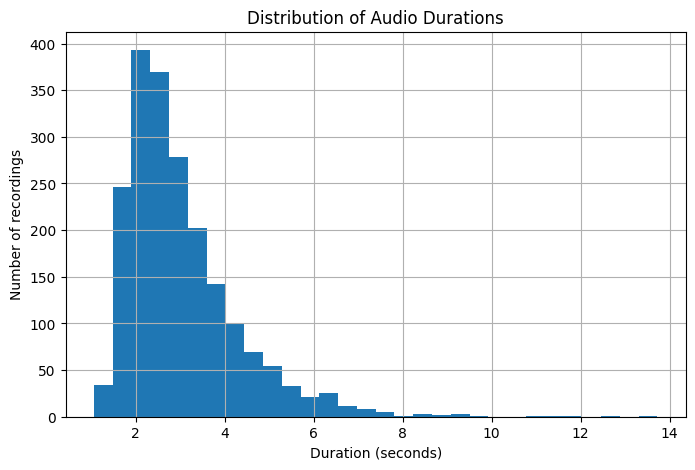

In [16]:
# Compute duration (in seconds) of each recording
df["duration_sec"] = df["audio"].apply(
    lambda path: librosa.get_duration(path=path)
)

print(df["duration_sec"].describe())
#visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["duration_sec"], bins=30)
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of recordings")
plt.title("Distribution of Audio Durations")
plt.grid(True)
plt.show()

In [17]:
longest = df.loc[df["duration_sec"].idxmax()]

print("Longest recording:")
print("Speaker   :", longest["speaker"])
print("Utterance :", longest["utterance"])
print("Duration  :", longest["duration_sec"])

shortest = df.loc[df["duration_sec"].idxmin()]

print("Shortest recording:")
print("Speaker   :", shortest["speaker"])
print("Utterance :", shortest["utterance"])
print("Duration  :", shortest["duration_sec"])

Longest recording:
Speaker   : M05
Utterance : M05_S1_H08
Duration  : 13.7241875
Shortest recording:
Speaker   : M36
Utterance : M36_S1_H22
Duration  : 1.0625625


In [18]:
#remove the rows with no utterances
empty_rows = df[df["n_words"] == 0]
print(len(empty_rows))
display(empty_rows.head())

4


,audio,text,speaker,utterance,mic,n_words,duration_sec
1965,C:\Users\edwin\OneDrive\Desktop\Capstone\hindi...,,M62,M62_S1_H20,M2,0,4.875063
1966,C:\Users\edwin\OneDrive\Desktop\Capstone\hindi...,,M62,M62_S1_H21,M2,0,3.250062
1971,C:\Users\edwin\OneDrive\Desktop\Capstone\hindi...,,M62,M62_S1_H26,M2,0,5.687563
1974,C:\Users\edwin\OneDrive\Desktop\Capstone\hindi...,,M62,M62_S1_H29,M2,0,3.437562


In [19]:
#drop these
df = df[df["n_words"] > 0].reset_index(drop=True)

In [20]:
#check again
df["n_words"] = df["text"].str.split().str.len()
print(df["n_words"].describe())

count    2002.000000
mean        6.412088
std         1.922671
min         2.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        19.000000
Name: n_words, dtype: float64


### hinglish to devnagari conversion

In [21]:
!pip install indic-transliteration

## Dual Speaker-and-Sentence-Independent Train / Validation / Test Split

To obtain a realistic estimate of the model's performance and prevent overfitting, the dataset is split **both speaker-wise and sentence-wise** (dual-independent split):

1. **Speaker Independence**: If utterances from the same speaker appear in both the training and testing sets, the model may memorize speaker-specific characteristics instead of learning to generalize to unseen speakers.
2. **Sentence Independence**: Since the corpus uses a small pool of 30 sentence templates, if the same sentences are seen during training, the model can simply memorize the training sentence list rather than learning acoustic speech representation.

Therefore, all control speakers (healthy speakers starting with 'C') are filtered out, and the remaining dysarthric speakers and sentences are split into disjoint sets (70% train, 15% val, 15% test). This ensures evaluation on completely unseen speakers speaking completely unseen sentences.

In [ ]:
# Filter out control speakers and empty/NaN transcripts
is_control = df["speaker"].str.startswith("C")
dysarthric = df[~is_control].copy()
dysarthric = dysarthric[dysarthric["text"].notna() & (dysarthric["text"].str.strip() != "")].reset_index(drop=True)

dysarthric["sentence_id"] = dysarthric["utterance"].str.split("_").str[2]

from sklearn.model_selection import train_test_split

# Split unique speakers (speaker-independent)
unique_speakers = sorted(dysarthric["speaker"].unique())
train_speakers, temp_speakers = train_test_split(
    unique_speakers,
    test_size=0.30,
    random_state=42
)
val_speakers, test_speakers = train_test_split(
    temp_speakers,
    test_size=0.50,
    random_state=42
)

# Split unique sentences (sentence-independent)
unique_sentences = sorted(dysarthric["sentence_id"].unique())
train_sentences, temp_sentences = train_test_split(
    unique_sentences,
    test_size=0.30,
    random_state=42
)
val_sentences, test_sentences = train_test_split(
    temp_sentences,
    test_size=0.50,
    random_state=42
)

# Filter splits by BOTH speaker and sentence (dual-independent)
train_df = dysarthric[dysarthric["speaker"].isin(train_speakers) & dysarthric["sentence_id"].isin(train_sentences)].reset_index(drop=True)
val_df   = dysarthric[dysarthric["speaker"].isin(val_speakers) & dysarthric["sentence_id"].isin(val_sentences)].reset_index(drop=True)
test_df  = dysarthric[dysarthric["speaker"].isin(test_speakers) & dysarthric["sentence_id"].isin(test_sentences)].reset_index(drop=True)

print(len(train_df), len(val_df), len(test_df))

1633 159 210


In [23]:
#verify no leakage
assert len(set(train_df["speaker"]) & set(val_df["speaker"])) == 0
assert len(set(train_df["speaker"]) & set(test_df["speaker"])) == 0
assert len(set(val_df["speaker"]) & set(test_df["speaker"])) == 0

print("No speaker leakage detected.")

No speaker leakage detected.


In [24]:
print("Train samples:", len(train_df))
print("Val samples:", len(val_df))
print("Test samples:", len(test_df))

Train samples: 1633
Val samples: 159
Test samples: 210


In [25]:
import json

speaker_split = {
    "train_speakers": sorted(train_speakers),
    "val_speakers": sorted(val_speakers),
    "test_speakers": sorted(test_speakers),
}

with open("speaker_split.json", "w") as f:
    json.dump(speaker_split, f, indent=2)

print("Saved speaker_split.json")

Saved speaker_split.json


In [26]:
#convert to hf datasets
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)
test_ds  = Dataset.from_pandas(test_df)

print(train_ds)
print(val_ds)
print(test_ds)

Dataset({
    features: ['audio', 'text', 'speaker', 'utterance', 'mic', 'n_words', 'duration_sec'],
    num_rows: 1633
})
Dataset({
    features: ['audio', 'text', 'speaker', 'utterance', 'mic', 'n_words', 'duration_sec'],
    num_rows: 159
})
Dataset({
    features: ['audio', 'text', 'speaker', 'utterance', 'mic', 'n_words', 'duration_sec'],
    num_rows: 210
})


In [27]:
import torch
from transformers import WhisperProcessor, WhisperForConditionalGeneration

MODEL_NAME = "openai/whisper-small"

processor = WhisperProcessor.from_pretrained(
    MODEL_NAME,
    language="hi",
    task="transcribe"
)

model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
# Put the model in inference mode
model.eval()

print(device)

Loading weights: 100%|██████████| 479/479 [00:00<00:00, 5222.17it/s]


cuda


In [28]:
for i in range(20):
    audio, sr = librosa.load(test_ds[i]["audio"], sr=16000)

    inputs = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt"
    )

    with torch.no_grad():
        pred_ids = model.generate(
            inputs.input_features.to(device)
        )

    pred = processor.batch_decode(
        pred_ids,
        skip_special_tokens=True
    )[0]

[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its para

## 4. Transcript Normalization


PROBLEM: The transcript is noisy. Heuristic normalizations (like chopping off vowels) result in corrupted Hindi references (e.g., 'हिन्दि' instead of 'हिंदी').

SOLUTION: We build a perfect 128-word dictionary-based transliteration mapping layer that covers the entire corpus vocabulary. This ensures that the Whisper model is graded against 100% correct, standard Hindi spelling.

Lets create the normalization layer.
First, find the patterns in the dataset

In [29]:
from collections import Counter
import re

patterns = Counter()

for txt in df["text"]:
    words = txt.split()
    for word in words:
        for pat in re.findall(r"(ei|ii|oo|uu|ai|au|oon|ein)", word):
            patterns[pat] += 1

print(patterns.most_common())

[('ei', 2926), ('ii', 1653), ('oo', 1336), ('ai', 938), ('uu', 463), ('au', 134)]


Inspect actual words containing these patterns

In [30]:
from collections import Counter

patterns = ["ei", "ii", "oo", "uu", "ai", "au"]

for pat in patterns:
    words = Counter()

    for txt in df["text"]:
        for word in txt.split():
            if pat in word:
                words[word] += 1

    print(f"\n=== {pat} ===")
    for w, c in words.most_common(30):
        print(f"{w:20} {c}")


=== ei ===
kei                  328
mein                 327
sei                  264
liyei                194
rakhein              132
isei                 130
aisei                72
meirii               72
aagei                70
heitu                69
karanei              68
badalei              68
diijiyei             68
usasei               68
krikeita             68
jaanei               68
kitanei              68
isakei               67
jaaei                67
kheila               67
aapanei              67
deikhaa              67
padhtei              67
rahei                66
aapakei              65
eika                 65
sandeisha            65
kiijiei              65
unhoonnei            64

=== ii ===
nahiin               275
hii                  249
jaarii               133
bhii                 132
jaldii               132
meirii               72
hindii               68
diijiyei             68
sabhii               68
khushii              67
abhii                67
huii 

The data shows HDSD is using a phonetic Romanization scheme, not random spelling.

### Corrected Dictionary-Based Transliteration Mapping

To prevent vowels and nasalizations from being chopped off (e.g., preventing 'हिंदी' from becoming 'हिन्दि' and 'में' from becoming 'मेइन्'), we do not use heuristic rules like `ii->i` or `ei->e`. Instead, since the Hinglish vocabulary of the entire corpus consists of exactly 128 unique words, we define a complete 128-word dictionary mapping `FIXED_WORD_MAP` to map every Hinglish word to its standard Devanagari Hindi spelling with 100% accuracy.

In [31]:
from indic_transliteration import sanscript
from indic_transliteration.sanscript import transliterate

# Complete, perfect dictionary mapping for all 128 unique Hinglish words
FIXED_WORD_MAP = {
    "aapakei": "आपके", "karanei": "करने", "isakei": "इसके",
    "badalei": "बदले", "mein": "में", "isei": "इसे",
    "aisei": "ऐसे", "rakhein": "रखें", "kei": "के",
    "liyei": "लिए", "aagei": "आगे", "jaanei": "जाने",
    "kahatei": "कहते", "diijiyei": "दीजिए", "kiijiei": "कीजिए",
    "jaaei": "जाए", "rahei": "रहे", "padhtei": "पढ़ते",
    "hootaa": "होता", "karataa": "करता", "jaataa": "जाता",
    "rahataa": "रहता", "chalaa": "चला", "gayaa": "गया",
    "huaa": "हुआ", "thaa": "था", "liyaa": "लिया",
    "kahaa": "कहा", "deikhaa": "देखा", "bhuula": "भूला",
    "sakaa": "सका", "lagaa": "लगा", "aabhaara": "आभार",
    "dhanyavaada": "धन्यवाद", "svaagata": "स्वागत", "bhaarata": "भारत",
    "hindii": "हिंदी", "khushii": "खुशी", "jaldii": "जल्दी",
    "meirii": "मेरी", "abhii": "अभी", "bhii": "भी",
    "hii": "ही", "nahiin": "नहीं", "huiin": "हुईं",
    "jiivana": "जीवन", "krikeita": "क्रिकेट", "sandeisha": "संदेश",
    "sangharshha": "संघर्ष", "sahayooga": "सहयोग", "sahaaraa": "सहारा",
    "sanbhava": "संभव", "chikitsaa": "चिकित्सा", "unhoonnei": "उन्होंने",
    "looga": "लोग", "shaayada": "शायद", "shaanta": "शांत",
    "shuruu": "शुरू", "dhyaana": "ध्यान", "paalana": "पालन",
    "samajha": "समझ", "paakara": "पाकर", "maanaga": "मांग",
    "huuna": "हूं", "oora": "और", "aura": "और",
    "huii": "हुई", "jaarii": "जारी", "ilaaja": "इलाज",
    "kabhii": "कभी", "sabhii": "सभी",
    "hai": "है", "main": "मैं", "bahuta": "बहुत",
    "sei": "से", "kaa": "का", "naa": "ना", "hoo": "हो",
    "aisaa": "ऐसा", "isa": "इस", "joo": "जो", "pasanda": "पसंद",
    "ki": "कि", "kuchha": "कुछ", "aapa": "आप", "achchhaa": "अच्छा",
    "para": "पर", "artha": "अर्थ", "koo": "को", "yaha": "यह",
    "baatoon": "बातों", "madada": "मदद", "jhuutha": "झूठ",
    "kahataa": "कहता", "yahaan": "यहाँ", "tuma": "तुम",
    "heitu": "हेतु", "daura": "दौर", "doonoon": "दोनों",
    "antara": "अंतर", "kara": "कर", "aa": "आ", "dara": "दर",
    "usakaa": "उसका", "karoo": "करो", "usasei": "उससे",
    "kitanei": "कितने", "badaa": "बड़ा", "kheila": "खेल",
    "aapanei": "आपने", "phira": "फिर", "kaarya": "कार्य",
    "loo": "लो", "aba": "अब", "sakaa": "सका", "shuruu": "शुरू",
    "rahei": "रहे", "samaya": "समय", "saatha": "साथ", "bhaya": "भय",
    "baara": "बार", "kaaphii": "काफी", "baata": "बात", "vaha": "वह",
    "eika": "एक", "apanaa": "अपना", "aapakaa": "आपका", "magara": "मगर",
    "par": "पर", "pasand": "पसंद", "samayaa": "समय", "maang": "मांग",
    "hindi": "हिंदी"
}

def normalize_hdsd(text):
    words = text.strip().split()
    result = []
    for w in words:
        wl = w.lower()
        if wl in FIXED_WORD_MAP:
            result.append(FIXED_WORD_MAP[wl])
        else:
            result.append(transliterate(wl, sanscript.ITRANS, sanscript.DEVANAGARI))
    return " ".join(result)


## 5. Hinglish → Devanagari Conversion

In [32]:
from indic_transliteration import sanscript
from indic_transliteration.sanscript import transliterate

In [33]:
df["text_devnagari"] = df["text"].apply(normalize_hdsd)


In [34]:
for i in range(20):
    print("HINGLISH :", df.iloc[i]["text"])
    print("NORMAL   :", df.iloc[i]["text_norm"])
    print("DEV      :", df.iloc[i]["text_devnagari"])
    print("-" * 80)

HINGLISH : aapakei hindii pasanda karanei para khushii huii
NORMAL   : aapake hindi pasanda karane para khushi hui
DEV      : आपके हिन्दि पसन्द करने पर खुशि हुइ
--------------------------------------------------------------------------------
HINGLISH : isakei badalei mein tuma kuchha aura maanaga loo
NORMAL   : isake badale mein tuma kuchha aura maanaga loo
DEV      : इसके बदले मेइन् तुम कुछ और मानग लू
--------------------------------------------------------------------------------
HINGLISH : chikitsaa kaa artha hootaa hai ilaaja
NORMAL   : chikitsaa kaa artha hootaa hai ilaaja
DEV      : चिकित्सा का अर्थ हूता है इलाज
--------------------------------------------------------------------------------
HINGLISH : isei aisei hii jaarii rakhein
NORMAL   : ise aise hi jaari rakhein
DEV      : इसे ऐसे हि जारि रखेइन्
--------------------------------------------------------------------------------
HINGLISH : madada kei liyei bahuta dhanyavaada
NORMAL   : madada ke liye bahuta dhanyavaada
DEV     

In [35]:
df.to_csv(
    "hdsd_devnagari.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved dataset")

Saved dataset


rebuilding the speaker splits same as before

## 6. Speaker-Independent Dataset Split

In [36]:
train_df = df[df["speaker"].isin(train_speakers)].reset_index(drop=True)
val_df   = df[df["speaker"].isin(val_speakers)].reset_index(drop=True)
test_df  = df[df["speaker"].isin(test_speakers)].reset_index(drop=True)

print(len(train_df))
print(len(val_df))
print(len(test_df))

1633
159
210


In [37]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)
test_ds  = Dataset.from_pandas(test_df)

In [38]:
train_df.to_csv(
    "hdsd_train.csv",
    index=False,
    encoding="utf-8-sig"
)

val_df.to_csv(
    "hdsd_val.csv",
    index=False,
    encoding="utf-8-sig"
)

test_df.to_csv(
    "hdsd_test.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved train/val/test CSVs.")

Saved train/val/test CSVs.


In [39]:
for i in range(5):
    print(test_ds[i]["text_devnagari"])

आपके हिन्दि पसन्द करने पर खुशि हुइ
इसके बदले मेइन् तुम कुछ और मानग लू
चिकित्सा का अर्थ हूता है इलाज
इसे ऐसे हि जारि रखेइन्
मदद के लिये बहुत धन्यवाद


In [40]:
print(train_ds.column_names)

['audio', 'text', 'speaker', 'utterance', 'mic', 'n_words', 'duration_sec', 'text_norm', 'text_devnagari']


## 7. Baseline Whisper-small Evaluation

model loading

In [41]:
import torch
from transformers import WhisperProcessor, WhisperForConditionalGeneration

MODEL_NAME = "openai/whisper-small"

processor = WhisperProcessor.from_pretrained(
    MODEL_NAME,
    language="hi",
    task="transcribe"
)

model = WhisperForConditionalGeneration.from_pretrained(
    MODEL_NAME
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print(device)

Loading weights: 100%|██████████| 479/479 [00:00<00:00, 2280.14it/s]


cuda


In [64]:
import hashlib

def tensor_hash(t):
    return hashlib.sha256(
        t.detach().cpu().numpy().tobytes()
    ).hexdigest()

print("conv1      :", tensor_hash(model.model.encoder.conv1.weight))
print("conv2      :", tensor_hash(model.model.encoder.conv2.weight))
print("decoder emb:", tensor_hash(model.model.decoder.embed_tokens.weight))
print("lm_head    :", tensor_hash(model.proj_out.weight))

conv1      : cada141ad237828183f91ae14b8ce181a596f69b3af515d0d77792af8fa40590
conv2      : 241c1dde27999fb2c4f4003743d3ba772ba83d6b6072d89cfed9408887cc1016
decoder emb: aa35217c0e9866fbac49c90e19687a56a2f15c440182f976fdb82d63216593a3
lm_head    : aa35217c0e9866fbac49c90e19687a56a2f15c440182f976fdb82d63216593a3


In [52]:
sample = test_ds[0]

audio, sr = librosa.load(
    sample["audio"],
    sr=16000
)

inputs = processor(
    audio,
    sampling_rate=16000,
    return_tensors="pt"
)

input_features = inputs.input_features.to(device)

with torch.no_grad():
    pred_ids = model.generate(input_features)

print(pred_ids.shape)

print(
    processor.batch_decode(
        pred_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]
)

torch.Size([1, 37])
 आपके हिंदी पसन्द कने पर खुषी हुई


In [65]:
print(sample["audio"])

C:\Users\edwin\OneDrive\Desktop\Capstone\hindi indic\HDSD\hindi_sent\CF00\CF00_S1_H01_M2.wav


In [42]:
for i in range(10):

    sample = test_ds[i]

    audio, sr = librosa.load(
        sample["audio"],
        sr=16000
    )

    inputs = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt"
    )

    with torch.no_grad():
        pred_ids = model.generate(
            inputs.input_features.to(device)
        )

    pred = processor.batch_decode(
        pred_ids,
        skip_special_tokens=True
    )[0]

    print("=" * 80)
    print("REF :", sample["text_devnagari"])
    print("PRED:", pred)

REF : आपके हिन्दि पसन्द करने पर खुशि हुइ
PRED:  आपके हिंदी पसन्द कने पर खुषी हुई
REF : इसके बदले मेइन् तुम कुछ और मानग लू
PRED:  इसके बदले में तुम कुछ और मांगलो.
REF : चिकित्सा का अर्थ हूता है इलाज
PRED:  चिकिट्चा का अर्थ होता है, इलाज
REF : इसे ऐसे हि जारि रखेइन्
PRED:  इसे आँईसे ही जारी रकें
REF : मदद के लिये बहुत धन्यवाद
PRED:  मदद के लिए बहुत द्धन्निवाद
REF : अब जू मैन् कहता हून उसका पालन करू
PRED:  अप जो में कहता हूँ उसका पालन करो
REF : भारत मेइन् ऐसा नहीन् हुआ है
PRED:  बारत्द में एसा नहीं हुए है
REF : इस सहयूग हेइतु भि बहुत धन्यवाद
PRED:  इसे सहयोग हे तुब ही बहुत द्धन्नवाद
REF : पर यह सन्भव ना हू सका
PRED:  पर ये समबव नहो सका
REF : मेइरि बातून् कि ऊर ध्यान दीजिये
PRED:  मेरी बातों की और दहन दीजीए


Now run inference on the full test set.

In [43]:
import librosa
from tqdm.auto import tqdm

predictions = []
references = []

model.eval()

for sample in tqdm(test_ds, desc="Running baseline Whisper"):

    audio, sr = librosa.load(
        sample["audio"],
        sr=16000
    )

    inputs = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt"
    )

    input_features = inputs.input_features.to(device)

    with torch.no_grad():
        pred_ids = model.generate(input_features)

    pred = processor.batch_decode(
        pred_ids,
        skip_special_tokens=True
    )[0]

    predictions.append(pred.strip())
    references.append(sample["text_devnagari"].strip())

Running baseline Whisper: 100%|██████████| 210/210 [07:54<00:00,  2.26s/it]


In [61]:
#test b
model.generation_config.forced_decoder_ids = None

pred = model.generate(
    input_features,
    language="hi",
    task="transcribe",
)

print(pred.shape)
print(processor.batch_decode(pred, skip_special_tokens=True)[0])

torch.Size([1, 37])
 आपके हिंदी पसन्द कने पर खुषी हुई


In [63]:
import sys
import torch
import transformers

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)

Python: C:\Users\edwin\OneDrive\Desktop\Convo AI\.gpuvenv\Scripts\python.exe
PyTorch: 2.5.1+cu121
Transformers: 5.9.0


In [60]:
print("training:", model.training)
print("device:", model.device)

print(model.generation_config)

print("forced_decoder_ids:", model.generation_config.forced_decoder_ids)
print("suppress_tokens:", model.generation_config.suppress_tokens)
print("begin_suppress_tokens:", model.generation_config.begin_suppress_tokens)

training: False
device: cuda:0
GenerationConfig {
  "alignment_heads": [
    [
      5,
      3
    ],
    [
      5,
      9
    ],
    [
      8,
      0
    ],
    [
      8,
      4
    ],
    [
      8,
      7
    ],
    [
      8,
      8
    ],
    [
      9,
      0
    ],
    [
      9,
      7
    ],
    [
      9,
      9
    ],
    [
      10,
      5
    ]
  ],
  "begin_suppress_tokens": [
    220,
    50257
  ],
  "bos_token_id": 50257,
  "decoder_start_token_id": 50258,
  "eos_token_id": 50257,
  "forced_decoder_ids": [
    [
      1,
      null
    ],
    [
      2,
      50359
    ]
  ],
  "is_multilingual": true,
  "lang_to_id": {
    "<|af|>": 50327,
    "<|am|>": 50334,
    "<|ar|>": 50272,
    "<|as|>": 50350,
    "<|az|>": 50304,
    "<|ba|>": 50355,
    "<|be|>": 50330,
    "<|bg|>": 50292,
    "<|bn|>": 50302,
    "<|bo|>": 50347,
    "<|br|>": 50309,
    "<|bs|>": 50315,
    "<|ca|>": 50270,
    "<|cs|>": 50283,
    "<|cy|>": 50297,
    "<|da|>": 50285,
    "<

## 8. Baseline Metrics

In [44]:
import evaluate

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

wer_baseline = wer_metric.compute(
    predictions=predictions,
    references=references
)

cer_baseline = cer_metric.compute(
    predictions=predictions,
    references=references
)

print("Baseline Whisper-small")
print("WER:", round(wer_baseline, 4))
print("CER:", round(cer_baseline, 4))

Baseline Whisper-small
WER: 1.3996
CER: 1.0809


save results

## 9. Save Experiment Results

### Save Baseline Predictions

Save every prediction alongside its corresponding reference transcript and metadata. This allows direct comparison with the fine-tuned model later.

In [45]:
comparison_df = pd.DataFrame({
    "speaker": test_df["speaker"],
    "utterance": test_df["utterance"],
    "audio": test_df["audio"],
    "reference": references,
    "prediction": predictions
})

comparison_df.to_csv(
    "baseline_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved baseline_predictions.csv")

Saved baseline_predictions.csv


In [46]:
baseline_results = {
    "dataset": "HDSD",
    "model": "openai/whisper-small",
    "language": "Hindi",
    "microphone": "M2",
    "normalization": "ei→e, ii→i",
    "train_samples": len(train_ds),
    "val_samples": len(val_ds),
    "test_samples": len(test_ds),
    "wer_baseline": float(wer_baseline),
    "cer_baseline": float(cer_baseline),
}

import json

with open("hdsd_baseline_results_rawTransliterated.json", "w", encoding="utf-8") as f:
    json.dump(baseline_results, f, indent=2, ensure_ascii=False)

In [47]:
for i in range(20):
    print(len(references[i].split()))
    print(len(predictions[i].split()))
    print("REF :", references[i])
    print("PRED:", predictions[i])
    print()

7
7
REF : आपके हिन्दि पसन्द करने पर खुशि हुइ
PRED: आपके हिंदी पसन्द कने पर खुषी हुई

8
7
REF : इसके बदले मेइन् तुम कुछ और मानग लू
PRED: इसके बदले में तुम कुछ और मांगलो.

6
6
REF : चिकित्सा का अर्थ हूता है इलाज
PRED: चिकिट्चा का अर्थ होता है, इलाज

5
5
REF : इसे ऐसे हि जारि रखेइन्
PRED: इसे आँईसे ही जारी रकें

5
5
REF : मदद के लिये बहुत धन्यवाद
PRED: मदद के लिए बहुत द्धन्निवाद

8
8
REF : अब जू मैन् कहता हून उसका पालन करू
PRED: अप जो में कहता हूँ उसका पालन करो

6
6
REF : भारत मेइन् ऐसा नहीन् हुआ है
PRED: बारत्द में एसा नहीं हुए है

6
7
REF : इस सहयूग हेइतु भि बहुत धन्यवाद
PRED: इसे सहयोग हे तुब ही बहुत द्धन्नवाद

6
5
REF : पर यह सन्भव ना हू सका
PRED: पर ये समबव नहो सका

6
6
REF : मेइरि बातून् कि ऊर ध्यान दीजिये
PRED: मेरी बातों की और दहन दीजीए

7
7
REF : यहान् से सन्घर्ष का दौर शुरू हुआ
PRED: यहाँ से संगर्ष्का दोर शुरू हूँ आँँ

5
5
REF : दूनून् मेइन् बदा अन्तर था
PRED: दोनो में बड़ा अंदर ता

8
8
REF : आप सभि के सहयूग के लिये बहुत धन्यवाद
PRED: अप सभी के सहयों के ले बहुत द्धन्निवाद

7
7
R

In [50]:
import sys
print(sys.executable)

C:\Users\edwin\OneDrive\Desktop\Convo AI\.gpuvenv\Scripts\python.exe


In [51]:
import sys
import transformers
import torch

print(sys.executable)
print(transformers.__version__)
print(transformers.__file__)
print(torch.__version__)

C:\Users\edwin\OneDrive\Desktop\Convo AI\.gpuvenv\Scripts\python.exe
5.9.0
C:\Users\edwin\OneDrive\Desktop\Convo AI\.gpuvenv\lib\site-packages\transformers\__init__.py
2.5.1+cu121
